In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="brain_phantom_dropout0_1"

In [3]:
def plot_dataset(data, slice=None, cmap='gray', num_rows=1, figsize=(5, 5), dpi=100):
    ''' 
    Plots a slice of dataset of form: [Slice, Height, Width, Channel]
    
    Parameters:
    -----------
    data : ndarray
        Dataset of form [Slice, Height, Width, Channel]
    slice : int, optional
        Slice index to display (default: 0)
    cmap : str, optional
        Colormap name (default: 'gray')
    num_rows : int, optional
        Number of rows for plot layout (default: 1, single row)
    figsize : tuple, optional
        Figure size (default: (5, 5))
    dpi : int, optional
        Figure dpi (default: 100)
    '''

    slice = 0 if slice is None else slice
    npcs = data.shape[3]
    
    # Calculate number of columns based on number of rows
    num_cols = int(np.ceil(npcs / num_rows))
    
    # Create figure with adjusted layout
    fig, axs = plt.subplots(num_rows, num_cols, figsize=figsize, constrained_layout=True, dpi=dpi)
    
    if cmap:
        plt.set_cmap(cmap)
    
    # Ensure axs is always a 2D array
    if num_rows == 1 and num_cols == 1:
        axs = np.array([[axs]])
    elif num_rows == 1:
        axs = axs.reshape(1, -1)
    elif num_cols == 1:
        axs = axs.reshape(-1, 1)
        
    # Plot data
    for ii in range(npcs):
        row = ii // num_cols
        col = ii % num_cols
        
        _data = np.abs(data[slice, :, :, ii])
        axs[row, col].imshow(_data)
        axs[row, col].set_title(f'{int(ii*(360/npcs))}° PC')
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
    
    # Hide empty subplots if any
    for ii in range(npcs, num_rows * num_cols):
        row = ii // num_cols
        col = ii % num_cols
        axs[row, col].set_visible(False)
    
    # Adjust layout to reduce space between subplots
    plt.tight_layout()
    plt.show()

In [4]:
dataset = mssfp.generate_ssfp_dataset(
    phantom_type='brain', 
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    rotation=90,
    useRotate=True, 
    useDeform=True
)


Generating phantom...
Generating 3D phantom: (120, 434, 362)
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (120, 256, 256, 4)


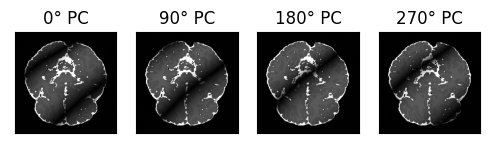

In [ ]:
mssfp.plot_dataset(dataset['M'], slice=1)

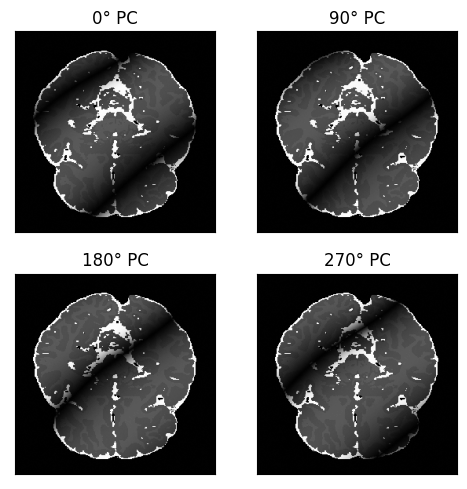

In [6]:
mssfp.plot_dataset(dataset['M'], slice=1, num_rows=2)

In [ ]:
slices = 500
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(40), 
    sigma=0.001, 
    useRotate=True, 
    useDeform=True,
    rotation=90,
    fn_offset=250
)


Generating phantom...
Generating SSFP dataset...


In [ ]:
mssfp.plot_dataset(dataset['M'], slice=1, dpi=120)